In [ ]:
!gdown --id 1KsFUoot7RpbKx4hryC4_zAtkB6IXtanY #เอาข้อมูลมา

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1KsFUoot7RpbKx4hryC4_zAtkB6IXtanY
To: /content/ws_dataset_01.csv
100% 3.96M/3.96M [00:00<00:00, 136MB/s]


In [ ]:
!pip install pythainlp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.3/19.3 MB 41.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

import re
import string
from pythainlp.corpus.common import thai_stopwords
from pythainlp import word_tokenize
from pythainlp.util import normalize

# สร้าง list ของคำหยุด (Stop words) ภาษาไทย เอาไว้ใช้หยุดคำที่ไม่มีความหมาย
th_stopwords = list(thai_stopwords()) #พวกคำเฉพาะ ช่องว่าง คำเชื่อมซ้ำๆ

In [ ]:
df = pd.read_csv("/content/ws_dataset_01.csv", usecols=["sentence", "label"]);# ระบุคอลัมน์
print("Dataset contains {:,} rows {} columns".format(df.shape[0], df.shape[1]))
df.head()

Dataset contains 5,836 rows 2 columns


,sentence,label
0,เน็ตควายมากกูพูดจริงเสียดายตังค์ที่ติดตั้งเน็ต...,neg
1,นับถอยหลังอีก 2 วัน สู่วีคเอน ถ้าวัยรุ่นยังไร้...,neu
2,นี่ก็เป็น ถ้าน้ำปกติกินเนดเล่ย์กับคริสตัลแต่น้...,neg
3,แอดมินต้องขออภัยในความไม่สะดวกจากใจจริงค่ะ หาก...,neu
4,ขอให้ SHEENe มีกิจการรุ่งเรือง ขายดีๆ ยอดไลท์เ...,pos


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5836 entries, 0 to 5835
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sentence  5836 non-null   object
 1   label     5836 non-null   object
dtypes: object(2)
memory usage: 91.3+ KB


In [ ]:
df.describe()

,sentence,label
count,5836,5836
unique,5836,3
top,ทีกับคนตรงข้าม เล่นเค้าจนสุดขั่ว พอทีนี้บอกลดร...,neu
freq,1,3502


In [ ]:
type(df)
df["label"].value_counts() #ข้อมูลส่วนมากจะไม่อินบาร์ลาน

,count
label,
neu,3502
neg,1739
pos,595


<Axes: xlabel='label'>

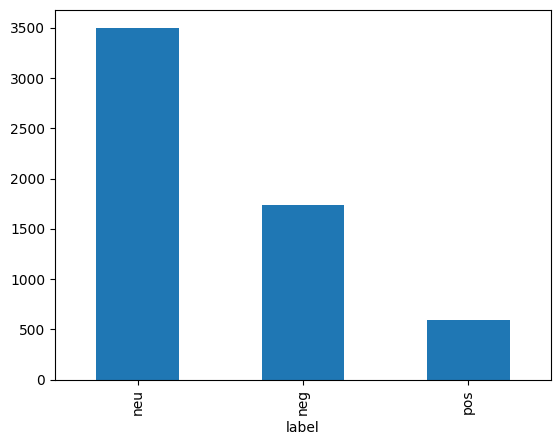

In [ ]:
df["label"].value_counts().plot.bar()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

import re
import string
from pythainlp.corpus.common import thai_stopwords
from pythainlp import word_tokenize
from pythainlp.util import normalize

def text_cleansing(sentence):


  # ==== Preprocessing ==== ตัดคำจากข้อความให้เป็น list
  tokens = word_tokenize(sentence, keep_whitespace=False)
  return '|'.join(tokens)

df['tokenize'] = df['sentence'].apply(text_cleansing) #สั่งมันจอยอีกครั้ง
df.head() #มีตัวคั่นกลาง และช่องว่างหายไป

,sentence,label,tokenize
0,เน็ตควายมากกูพูดจริงเสียดายตังค์ที่ติดตั้งเน็ต...,neg,เน็ต|ควาย|มาก|กู|พูด|จริง|เสียดาย|ตังค์|ที่|ติ...
1,นับถอยหลังอีก 2 วัน สู่วีคเอน ถ้าวัยรุ่นยังไร้...,neu,นับ|ถอยหลัง|อีก|2|วัน|สู่|วีค|เอน|ถ้า|วัยรุ่น|...
2,นี่ก็เป็น ถ้าน้ำปกติกินเนดเล่ย์กับคริสตัลแต่น้...,neg,นี่|ก็|เป็น|ถ้า|น้ำ|ปกติ|กิน|เนดเล่ย์|กับ|คริส...
3,แอดมินต้องขออภัยในความไม่สะดวกจากใจจริงค่ะ หาก...,neu,แอดมิน|ต้อง|ขออภัย|ใน|ความไม่สะดวก|จาก|ใจจริง|...
4,ขอให้ SHEENe มีกิจการรุ่งเรือง ขายดีๆ ยอดไลท์เ...,pos,ขอให้|SHEENe|มี|กิจการ|รุ่งเรือง|ขายดี|ๆ|ยอด|ไ...


In [ ]:
# ==== คำที่เกิดขึ้นบ่อยใน class pos ====
polar_pos = dict()
text_pos = df[df["label"]=="pos"]['tokenize'].sum().split("|")
for i in text_pos:
  if i not in polar_pos:
    polar_pos[i] = 1 #ถ้าเจอครั้งแรกให้เป็น 1
  else:
    polar_pos[i] += 1 #ถ้าเจอหลายครั้งแล้วให้ +1 ก็จะกลายเป็น 2
k = list(polar_pos.keys())
for i in k:
  if polar_pos[i] < 20:
    del polar_pos[i]
polar_pos = sorted(polar_pos.items(), key=lambda x: x[1], reverse=True)
polar_pos[:100] #จะได้คำนั้นซ้ำได้เท่าไหร่

[('ที่', 559),
 ('ไม่', 495),
 ('ได้', 365),
 ('ๆ', 350),
 ('ไป', 332),
 ('เลย', 329),
 ('มา', 321),
 ('และ', 307),
 ('มี', 302),
 ('ก็', 291),
 ('ของ', 278),
 ('ให้', 263),
 ('#', 262),
 ('มาก', 261),
 ('เป็น', 258),
 ('จะ', 251),
 ('ค่ะ', 249),
 ('ใช้', 226),
 ('แล้ว', 204),
 ('กับ', 198),
 ('เรา', 192),
 ('ว่า', 191),
 ('ใน', 187),
 ('แต่', 171),
 ('นี้', 169),
 ('ด้วย', 168),
 ('ดี', 160),
 ('ผิว', 160),
 ('ชอบ', 156),
 ('เพราะ', 152),
 ('คือ', 144),
 ('กัน', 120),
 ('มัน', 120),
 ('สวย', 119),
 ('.', 116),
 ('แบบ', 114),
 ('ต้อง', 111),
 ('คน', 109),
 ('นะ', 104),
 ('หน้า', 103),
 ('อยาก', 100),
 ('จาก', 100),
 ('รถ', 96),
 ('กก', 95),
 ('ครับ', 90),
 ('ดู', 89),
 ('การ', 89),
 ('อยู่', 85),
 ('ทั้ง', 82),
 ('ยัง', 80),
 ('ช่วย', 79),
 ('ทุก', 75),
 ('ลอง', 73),
 ('ตัว', 73),
 ('อร่อย', 71),
 ('กว่า', 71),
 ('กิน', 70),
 ('2', 70),
 ('ซื้อ', 69),
 (')', 66),
 ('อย่าง', 66),
 ('(', 65),
 ('ถ้า', 64),
 ('ใหม่', 64),
 ('สุด', 64),
 ('อีก', 63),
 ('ความ', 63),
 ('ทา', 63),
 ('เหมือน',

ทำ Preprocessing

In [ ]:
def text_cleansing(sentence):

  # ==== Preprocessing ==== ตัดคำจากข้อความให้เป็น list

  sentence = re.sub(r'[0-9]+', ' ', sentence)
  sentence = re.sub(r'\s+', ' ', sentence)
  sentence = sentence.translate(str.maketrans(dict.fromkeys(string.punctuation)))
  sentence = normalize(sentence) # normalize คือ แก้คำผิดให้ถูก แก้ออร์เดอร์ผิดให้ถูก เช่น เเ เป็น แ

  # ==== Preprocessing ==== ตัดคำจากข้อความให้เป็น list
  tokens = word_tokenize(sentence, keep_whitespace=False) #sentence แทน tokenize

  # ==== Preprocessing ==== นำคำที่เป็นคำหยุดออกจาก list คำที่ตัดแล้ว
  tokens = [word for word in tokens if word not in th_stopwords] #ตัดคำแปลกๆออก หรือไม่จำเป็นออก

  # ==== Preprocessing ==== เชื่อมคำใน list ด้วยเครื่องหมาย "|"
  return '|'.join(tokens)

df['preprocessed'] = df['sentence'].apply(text_cleansing)
df.head() #ทำ Preprocessing เพื่อลดจำนวนคำ

,sentence,label,tokenize,preprocessed
0,เน็ตควายมากกูพูดจริงเสียดายตังค์ที่ติดตั้งเน็ต...,neg,เน็ต|ควาย|มาก|กู|พูด|จริง|เสียดาย|ตังค์|ที่|ติ...,เน็ต|ควาย|เสียดาย|ตังค์|ติดตั้ง|เน็ต|โค|รต|ห่ว...
1,นับถอยหลังอีก 2 วัน สู่วีคเอน ถ้าวัยรุ่นยังไร้...,neu,นับ|ถอยหลัง|อีก|2|วัน|สู่|วีค|เอน|ถ้า|วัยรุ่น|...,ถอยหลัง|วีค|เอน|วัยรุ่น|ไร้|โปรแกรม|เก๋|แนะนำ|...
2,นี่ก็เป็น ถ้าน้ำปกติกินเนดเล่ย์กับคริสตัลแต่น้...,neg,นี่|ก็|เป็น|ถ้า|น้ำ|ปกติ|กิน|เนดเล่ย์|กับ|คริส...,น้ำ|ปกติ|กิน|เนดเล่ย์|คริสตัล|น้ำแร่|กิน|ออ|ร่...
3,แอดมินต้องขออภัยในความไม่สะดวกจากใจจริงค่ะ หาก...,neu,แอดมิน|ต้อง|ขออภัย|ใน|ความไม่สะดวก|จาก|ใจจริง|...,แอดมิน|ขออภัย|ความไม่สะดวก|ใจจริง|กรอบรูป|วันเ...
4,ขอให้ SHEENe มีกิจการรุ่งเรือง ขายดีๆ ยอดไลท์เ...,pos,ขอให้|SHEENe|มี|กิจการ|รุ่งเรือง|ขายดี|ๆ|ยอด|ไ...,ขอให้|SHEENe|กิจการ|รุ่งเรือง|ขายดี|ยอด|ไลท์|เ...


In [ ]:
# ==== คำที่เกิดขึ้นบ่อยใน class pos ====
polar_pos = dict()
text_pos = df[df["label"]=="pos"]['preprocessed'].sum().split("|")
for i in text_pos:
  if i not in polar_pos:
    polar_pos[i] = 1
  else:
    polar_pos[i] += 1
k = list(polar_pos.keys())
for i in k:
  if polar_pos[i] < 20:
    del polar_pos[i]
polar_pos = sorted(polar_pos.items(), key=lambda x: x[1], reverse=True)
polar_pos[:5] # ตัดพวกคำออก
print(len(polar_pos))

119


In [ ]:
polar_neg = dict()
text_neg = df[df["label"]=="neg"]['preprocessed'].sum().split("|")
for i in text_neg:
  if i not in polar_neg:
    polar_neg[i] = 1
  else:
    polar_neg[i] += 1
k = list(polar_neg.keys())
for i in k:
  if polar_neg[i] < 20:
    del polar_neg[i]
polar_neg = sorted(polar_neg.items(), key=lambda x: x[1], reverse=True)
polar_neg[:5]
print(len(polar_neg))

343


In [ ]:
polar_neu = dict()
text_neu = df[df["label"]=="neu"]['preprocessed'].sum().split("|")
for i in text_neu:
  if i not in polar_neu:
    polar_neu[i] = 1
  else:
    polar_neu[i] += 1
k = list(polar_neu.keys())
for i in k:
  if polar_neu[i] < 20:
    del polar_neu[i]
polar_neu = sorted(polar_neu.items(), key=lambda x: x[1], reverse=True)
polar_neu[:5]
print(len(polar_neu))

1176


1. ให้ลบคำที่ซ้ำกันจากทั้งสอง list ออก polar_pos,
polar_neg,polar_nue

2. เอาผลลัพธ์ไปใส่ใน cell ถัดไป

In [ ]:
# ดึงเฉพาะคำออกมาเป็น set
words_pos = {word for word, count in polar_pos}
'''words_pos = {}
for word, count in polar_pos:
  if word not in words_pos:
    words_pos[word] = count'''

words_neg = {word for word, count in polar_neg}
words_nue = {word for word, count in polar_neu}


'''common_words =
for word, count in words_pos:
  if word in  words_neg:
    common_words.append(word)'''

common_words = []
common_words = words_pos.intersection(words_neg)
common_words = common_words.intersection(words_nue)

# ลบคำที่ซ้ำออกจากทั้งสอง list
filtered_polar_pos = [(word, count) for word, count in polar_pos if word not in common_words]
filtered_polar_neg = [(word, count) for word, count in polar_neg if word not in common_words]
filtered_polar_neu = [(word, count) for word, count in polar_neu if word not in common_words]

In [ ]:
print("polar_pos (after removing )")
print(len(polar_pos), ' -> ', len(filtered_polar_pos))
print(filtered_polar_pos[:10])

polar_pos (after removing )
119  ->  29
[('ดีมาก', 44), ('แป้ง', 42), ('นุ่ม', 40), ('กันแดด', 38), ('สูตร', 37), ('แบคทีเรีย', 34), ('แดด', 33), ('ใส', 30), ('ขอบคุณ', 28), ('Honda', 27)]


In [ ]:
print("polar_neg (after removing )")
print(len(polar_neg), ' -> ',len(filtered_polar_neg))
print(filtered_polar_neg[:10])

polar_neg (after removing )
343  ->  253
[('แพง', 165), ('ขาย', 162), ('แบบนี้', 131), ('พนักงาน', 131), ('รอ', 118), ('บุหรี่', 114), ('สาขา', 109), ('ถาม', 109), ('อี', 104), ('บริการ', 92)]


In [ ]:
print("polar_neu (after removing )")
print(len(polar_neu), ' -> ',len(filtered_polar_neu))
print(filtered_polar_neu[:10])

polar_neu (after removing )
1176  ->  1086
[('บัตร', 474), ('”', 350), ('สาขา', 348), ('วันที่', 313), ('แป้ง', 279), ('โรงพยาบาล', 278), ('ฟรี', 276), ('รักษา', 265), ('มะเร็ง', 264), ('ชั้น', 259)]


In [ ]:
polar_pos = ["ดี", "ชอบ", "สวย", "อร่อย", "ดีมาก", "ขอบคุณ", "สนุก", "น่ารัก"]
polar_neg = ["แพง", "แพ้", "มีปัญหา", "แย่", "กลัว", "ด่า", "ห่วย", "เกลียด","โมโห"]

def count_polar_pos(sentence):
  tokens = sentence.split("|")
  num = len(list(set(tokens) & set(polar_pos)))
  return num

def count_polar_neg(sentence):
  tokens = sentence.split("|")
  num = len(list(set(tokens) & set(polar_neg)))
  return num

def predict_from_polar(row):
  if row["num_pos"] > row["num_neg"]:#pos
    return "pos"
  elif row["num_pos"] < row["num_neg"]:#neg.
    return "neg"
  else:
    return "neu"

simple_analysis = df[["preprocessed", "label"]].copy()
simple_analysis["num_pos"] = pd.Series(map(count_polar_pos, simple_analysis["preprocessed"]), dtype='int32')
simple_analysis["num_neg"] = pd.Series(map(count_polar_neg, simple_analysis["preprocessed"]), dtype='int32')
simple_analysis["predict"] = simple_analysis.apply (lambda row: predict_from_polar(row), axis=1)
simple_analysis.head()

,preprocessed,label,num_pos,num_neg,predict
0,เน็ต|ควาย|เสียดาย|ตังค์|ติดตั้ง|เน็ต|โค|รต|ห่ว...,neg,0,3,neg
1,ถอยหลัง|วีค|เอน|วัยรุ่น|ไร้|โปรแกรม|เก๋|แนะนำ|...,neu,0,0,neu
2,น้ำ|ปกติ|กิน|เนดเล่ย์|คริสตัล|น้ำแร่|กิน|ออ|ร่...,neg,0,0,neu
3,แอดมิน|ขออภัย|ความไม่สะดวก|ใจจริง|กรอบรูป|วันเ...,neu,0,0,neu
4,ขอให้|SHEENe|กิจการ|รุ่งเรือง|ขายดี|ยอด|ไลท์|เ...,pos,0,0,neu


In [ ]:
polar_pos = ["ดี", "ชอบ", "สวย", "อร่อย", "ดีมาก", "ขอบคุณ", "สนุก", "น่ารัก"]

for i in filtered_polar_pos:
  polar_pos.append(i[0])

print(polar_pos)

polar_neg = ["แพง", "แพ้", "มีปัญหา", "แย่", "กลัว", "ด่า", "ห่วย", "เกลียด","โมโห"]
for i in filtered_polar_neg:
  polar_neg.append(i[0])

def count_polar_pos(sentence):
  tokens = sentence.split("|")
  num = len(list(set(tokens) & set(polar_pos)))
  return num

def count_polar_neg(sentence):
  tokens = sentence.split("|")
  num = len(list(set(tokens) & set(polar_neg)))
  return num

def predict_from_polar(row):
  if row["num_pos"] > row["num_neg"]:
    return "pos"
  elif row["num_pos"] < row["num_neg"]:
    return "neg"
  else:
    return "neu"

simple_analysis = df[["preprocessed", "label"]].copy()
simple_analysis["num_pos"] = pd.Series(map(count_polar_pos, simple_analysis["preprocessed"]), dtype='int32')
simple_analysis["num_neg"] = pd.Series(map(count_polar_neg, simple_analysis["preprocessed"]), dtype='int32')
simple_analysis["predict"] = simple_analysis.apply (lambda row: predict_from_polar(row), axis=1)
simple_analysis[0:100]

['ดี', 'ชอบ', 'สวย', 'อร่อย', 'ดีมาก', 'ขอบคุณ', 'สนุก', 'น่ารัก', 'ดีมาก', 'แป้ง', 'นุ่ม', 'กันแดด', 'สูตร', 'แบคทีเรีย', 'แดด', 'ใส', 'ขอบคุณ', 'Honda', 'สด', 'สาร', 'แต่งหน้า', 'สนุก', 'แน่นอน', 'เนียน', 'ร้า', 'น่ารัก', 'ผิวหน้า', 'สาว', 'น้ำหอม', 'เหมาะกับ', 'ไปดู', 'ผลิตภัณฑ์', 'ลอรีเอะ', 'ใจ', 'หวาน', 'มั่นใจ', 'ประหยัด']


,preprocessed,label,num_pos,num_neg,predict
0,เน็ต|ควาย|เสียดาย|ตังค์|ติดตั้ง|เน็ต|โค|รต|ห่ว...,neg,0,22,neg
1,ถอยหลัง|วีค|เอน|วัยรุ่น|ไร้|โปรแกรม|เก๋|แนะนำ|...,neu,0,4,neg
2,น้ำ|ปกติ|กิน|เนดเล่ย์|คริสตัล|น้ำแร่|กิน|ออ|ร่...,neg,0,3,neg
3,แอดมิน|ขออภัย|ความไม่สะดวก|ใจจริง|กรอบรูป|วันเ...,neu,0,3,neg
4,ขอให้|SHEENe|กิจการ|รุ่งเรือง|ขายดี|ยอด|ไลท์|เ...,pos,0,3,neg
...,...,...,...,...,...
95,ขอให้|ลอรีเอะ|ซุปเปอร์|อัลต|ร้า|สลิม|ผ่า|อนามั...,neu,3,2,pos
96,ดู|ความเร็ว|ทางตรง|ดู|ความเร็ว|คดเคี้ยว|jazz|v...,neg,0,0,neu
97,นิสสัน|เตรียม|เปิดตัว|จีที|อาร์|เจ้าของ|ตำนาน|...,neu,0,2,neg
98,สวย|แกร่ง|ทันสมัย|นิสสัน|นาวา|ร่า|คัน|ซิง|เก้|...,neu,1,3,neg


1. ให้นิสิต เพิ่ม featrue num_nue
2. ให้นิสิต นับจำนวน polar word ของ class neu เพื่อกำหนดให้เป็นค่าของ featrue num_nue
3. คำนวณโดยเปรียบเทียบ number of polar word ของทั้ง 3 classes แล้ว predict class ของแต่ละ sentence input

In [ ]:
polar_pos = ["ดี", "ชอบ", "สวย", "อร่อย", "ดีมาก", "ขอบคุณ", "สนุก", "น่ารัก"]
for i in filtered_polar_pos:
  polar_pos.append(i[0])

polar_neg = ["แพง", "แพ้", "มีปัญหา", "แย่", "กลัว", "ด่า", "ห่วย", "เกลียด","โมโห"]
for i in filtered_polar_neg:
  polar_neg.append(i[0])

polar_neu = []
for i in filtered_polar_neu:
  polar_neu.append(i[0])

def count_polar_pos(sentence):
  tokens = sentence.split("|")
  num = len(list(set(tokens) & set(polar_pos)))
  return num

def count_polar_neg(sentence):
  tokens = sentence.split("|")
  num = len(list(set(tokens) & set(polar_neg)))
  return num

def count_polar_neu(sentence):
  tokens = sentence.split("|")
  num = len(list(set(tokens) & set(polar_neu)))
  return num

def predict_from_polar(row):
  maximum = max(row["num_pos"], row["num_neg"], row['num_neu'])
  if(row["num_pos"] == maximum) :
      return "pos"

  if(row["num_neg"] == maximum) :
    return "neg"

  return "neu"

simple_analysis = df[["preprocessed", "label"]].copy()
simple_analysis["num_pos"] = pd.Series(map(count_polar_pos, simple_analysis["preprocessed"]), dtype='int32')
simple_analysis["num_neg"] = pd.Series(map(count_polar_neg, simple_analysis["preprocessed"]), dtype='int32')
simple_analysis["num_neu"] = pd.Series(map(count_polar_neu, simple_analysis["preprocessed"]), dtype='int32')
simple_analysis["predict"] = simple_analysis.apply (lambda row: predict_from_polar(row), axis=1)
simple_analysis[3000:3050]

,preprocessed,label,num_pos,num_neg,num_neu,predict
3000,หิว|กิน|พี่|หัวหน้า|สั่ง|แมค|แพง|😂|นึกถึง|ร้าน...,neg,0,4,6,neu
3001,อ่าน|เจอ|่|ราคา|โอเค|งด|ดีกว่า|เดือน|ซื้อ|SM|ข...,neu,0,3,2,neg
3002,ผม|คน|นึง|ชอบ|ลอง|ดื่มเหล้า|แปลก|ดื่ม|พอได้|ลอ...,neg,1,2,2,neg
3003,ดี|ตรงไหน|ว่ะ|แมง|ซื่อ|วิ่ง|กิโล|ซิ|ล|หน้า|เกี...,neg,1,15,22,neu
3004,Neutrogena|Rainbath|Pomegranate|ทำความสะอาด|ฟื...,neu,2,6,30,neu
3005,💡|รู้|💡|ผู้ป่วย|อัมพฤกษ์|อัมพาต|ดูแล|ฟื้นฟู|สม...,neu,0,10,41,neu
3006,ลับ|ลวง|พราง|อิตาเลียน|ไทย|หน้ะ|กลืน|กิน|สังคม...,neg,0,2,3,neu
3007,ตำ|ร้าน|tasty|ติดกับ|LCC|อร่อย|จา|เมีย|น|จาน|ก...,pos,1,3,4,neu
3008,ความสุข|ไม่ต้อง|รูปแบบ|ขีดสุด|กลมกล่อม|ลงตัว|ค...,neu,2,1,9,neu
3009,ปล่อย|ภาพ|Teaser|ระยะไกล|เตรียม|เปิดตัว|รถ|รุ่...,neu,0,1,6,neu


In [ ]:
ft = (simple_analysis["num_pos"]>0) | (simple_analysis["num_neg"]>0)
simple_analysis[ft].head()

,preprocessed,label,num_pos,num_neg,num_neu,predict
0,เน็ต|ควาย|เสียดาย|ตังค์|ติดตั้ง|เน็ต|โค|รต|ห่ว...,neg,0,22,20,neg
1,ถอยหลัง|วีค|เอน|วัยรุ่น|ไร้|โปรแกรม|เก๋|แนะนำ|...,neu,0,4,18,neu
2,น้ำ|ปกติ|กิน|เนดเล่ย์|คริสตัล|น้ำแร่|กิน|ออ|ร่...,neg,0,3,3,neg
3,แอดมิน|ขออภัย|ความไม่สะดวก|ใจจริง|กรอบรูป|วันเ...,neu,0,3,11,neu
4,ขอให้|SHEENe|กิจการ|รุ่งเรือง|ขายดี|ยอด|ไลท์|เ...,pos,0,3,10,neu


Accuracy score: 0.6696


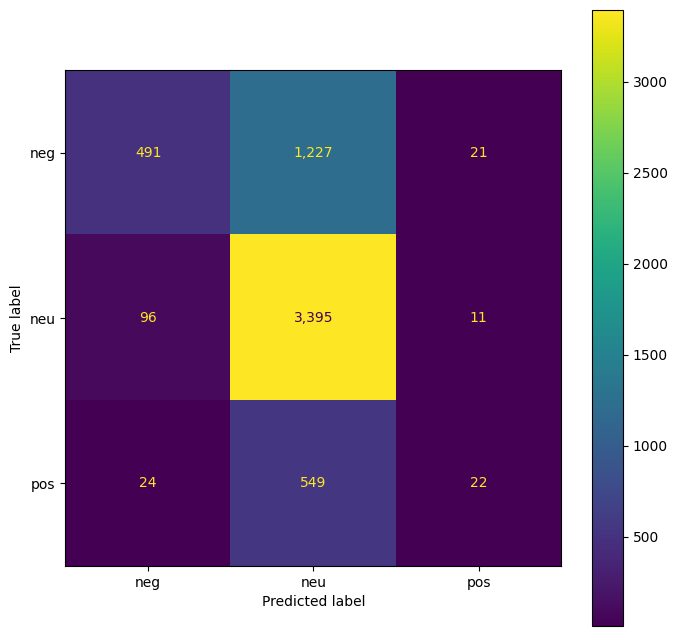

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


cm = confusion_matrix(simple_analysis["label"], simple_analysis["predict"]) #normalize="all"
ac = accuracy_score(simple_analysis["label"], simple_analysis["predict"])
print("Accuracy score: {:.4f}".format(ac))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["neg", "neu", "pos"])
fig, ax = plt.subplots(figsize=(8,8))
disp.plot(ax=ax, values_format=",d")

Accuracy score: 0.6696


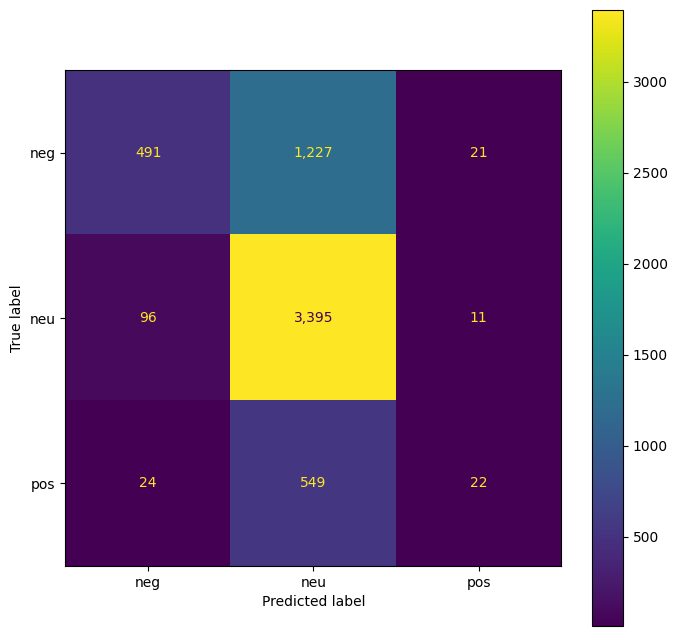

In [ ]:
def showConfisionMatrix(label, predict):
  cm = confusion_matrix(label, predict)
  ac = accuracy_score(label, predict)
  print("Accuracy score: {:.4f}".format(ac))
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["neg", "neu", "pos"])
  fig, ax = plt.subplots(figsize=(8,8))
  disp.plot(ax=ax, values_format=",d")

showConfisionMatrix(simple_analysis["label"], simple_analysis["predict"])

In [ ]:
simple_analysis["num_tokens"] = simple_analysis['preprocessed'].apply(lambda x: len(x.split('|')))
simple_analysis.head()

,preprocessed,label,num_pos,num_neg,num_neu,predict,num_tokens
0,เน็ต|ควาย|เสียดาย|ตังค์|ติดตั้ง|เน็ต|โค|รต|ห่ว...,neg,0,22,20,neg,65
1,ถอยหลัง|วีค|เอน|วัยรุ่น|ไร้|โปรแกรม|เก๋|แนะนำ|...,neu,0,4,18,neu,42
2,น้ำ|ปกติ|กิน|เนดเล่ย์|คริสตัล|น้ำแร่|กิน|ออ|ร่...,neg,0,3,3,neg,15
3,แอดมิน|ขออภัย|ความไม่สะดวก|ใจจริง|กรอบรูป|วันเ...,neu,0,3,11,neu,22
4,ขอให้|SHEENe|กิจการ|รุ่งเรือง|ขายดี|ยอด|ไลท์|เ...,pos,0,3,10,neu,15


In [ ]:
simple_analysis['unique_tokens_ratio'] = simple_analysis.apply(lambda row: len(set(row['preprocessed'].split('|'))) / row['num_tokens'] if row['num_tokens'] > 0 else 0, axis=1)
simple_analysis.head()

,preprocessed,label,num_pos,num_neg,num_neu,predict,num_tokens,unique_tokens_ratio
0,เน็ต|ควาย|เสียดาย|ตังค์|ติดตั้ง|เน็ต|โค|รต|ห่ว...,neg,0,22,20,neg,65,0.753846
1,ถอยหลัง|วีค|เอน|วัยรุ่น|ไร้|โปรแกรม|เก๋|แนะนำ|...,neu,0,4,18,neu,42,0.952381
2,น้ำ|ปกติ|กิน|เนดเล่ย์|คริสตัล|น้ำแร่|กิน|ออ|ร่...,neg,0,3,3,neg,15,0.866667
3,แอดมิน|ขออภัย|ความไม่สะดวก|ใจจริง|กรอบรูป|วันเ...,neu,0,3,11,neu,22,0.772727
4,ขอให้|SHEENe|กิจการ|รุ่งเรือง|ขายดี|ยอด|ไลท์|เ...,pos,0,3,10,neu,15,0.933333


normalized_sentiment_score = (num_pos - num_neg) / (num_pos + num_neg)



In [ ]:
simple_analysis['normalized_sentiment_score'] = simple_analysis.apply(lambda row: (row['num_pos'] - row['num_neg']) / (row['num_pos'] + row['num_neg']) if (row['num_pos'] + row['num_neg']) > 0 else 0, axis=1)
simple_analysis.head()
simple_analysis[0:100]

,preprocessed,label,num_pos,num_neg,num_neu,predict,num_tokens,unique_tokens_ratio,normalized_sentiment_score
0,เน็ต|ควาย|เสียดาย|ตังค์|ติดตั้ง|เน็ต|โค|รต|ห่ว...,neg,0,22,20,neg,65,0.753846,-1.000000
1,ถอยหลัง|วีค|เอน|วัยรุ่น|ไร้|โปรแกรม|เก๋|แนะนำ|...,neu,0,4,18,neu,42,0.952381,-1.000000
2,น้ำ|ปกติ|กิน|เนดเล่ย์|คริสตัล|น้ำแร่|กิน|ออ|ร่...,neg,0,3,3,neg,15,0.866667,-1.000000
3,แอดมิน|ขออภัย|ความไม่สะดวก|ใจจริง|กรอบรูป|วันเ...,neu,0,3,11,neu,22,0.772727,-1.000000
4,ขอให้|SHEENe|กิจการ|รุ่งเรือง|ขายดี|ยอด|ไลท์|เ...,pos,0,3,10,neu,15,0.933333,-1.000000
...,...,...,...,...,...,...,...,...,...
95,ขอให้|ลอรีเอะ|ซุปเปอร์|อัลต|ร้า|สลิม|ผ่า|อนามั...,neu,3,2,7,neu,14,1.000000,0.200000
96,ดู|ความเร็ว|ทางตรง|ดู|ความเร็ว|คดเคี้ยว|jazz|v...,neg,0,0,1,neu,10,0.800000,0.000000
97,นิสสัน|เตรียม|เปิดตัว|จีที|อาร์|เจ้าของ|ตำนาน|...,neu,0,2,11,neu,19,1.000000,-1.000000
98,สวย|แกร่ง|ทันสมัย|นิสสัน|นาวา|ร่า|คัน|ซิง|เก้|...,neu,1,3,5,neu,16,1.000000,-0.500000


Features X and target y defined successfully.
Accuracy score: 0.6696


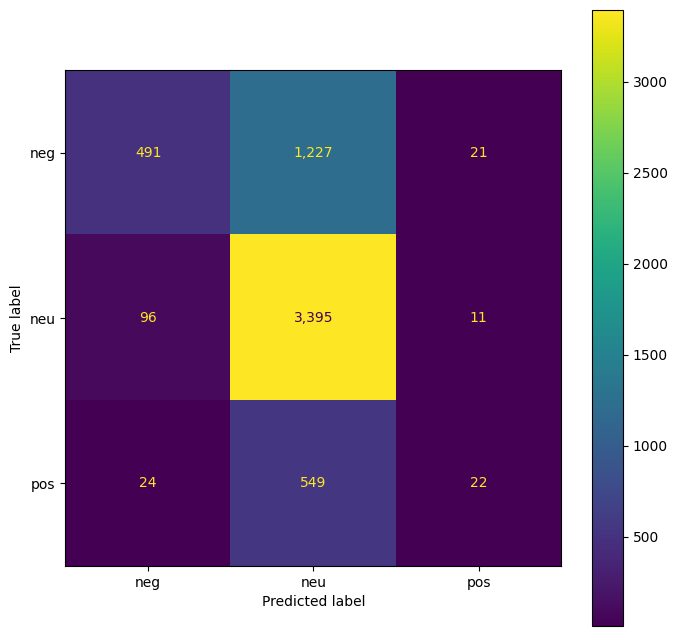

In [ ]:
X = simple_analysis[['num_pos', 'num_neg', 'num_neu', 'num_tokens', 'unique_tokens_ratio', 'normalized_sentiment_score']]
y = simple_analysis['label']

print("Features X and target y defined successfully.")
cm = confusion_matrix(simple_analysis["label"], simple_analysis["predict"]) #normalize="all"
ac = accuracy_score(simple_analysis["label"], simple_analysis["predict"])
print("Accuracy score: {:.4f}".format(ac))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["neg", "neu", "pos"])
fig, ax = plt.subplots(figsize=(8,8))
disp.plot(ax=ax, values_format=",d")

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets successfully.
X_train shape: (4668, 6)
X_test shape: (1168, 6)
y_train shape: (4668,)
y_test shape: (1168,)


In [ ]:
from sklearn.svm import SVC

svm_model = SVC(random_state=42)
svm_model.fit(X_train, y_train)
print("SVM model trained successfully.")

SVM model trained successfully.


Predictions made on the test set.
Accuracy score: 0.7260


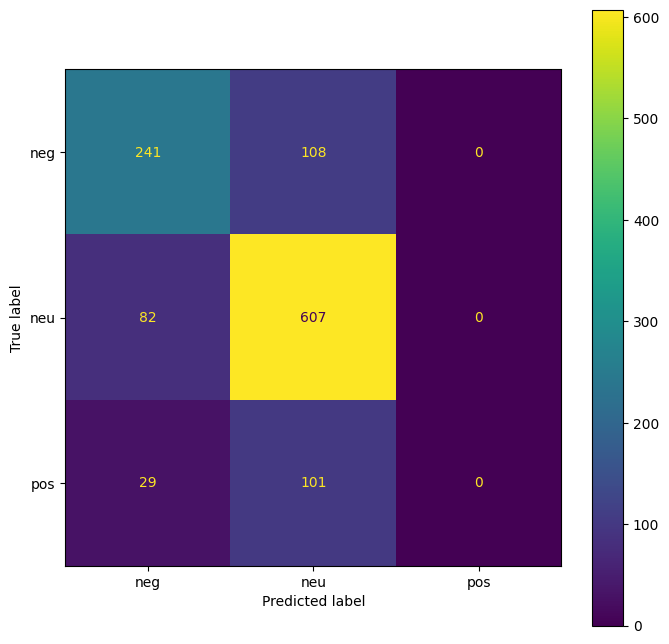

In [ ]:
y_pred = svm_model.predict(X_test)
print("Predictions made on the test set.")
showConfisionMatrix(y_test, y_pred)

In [ ]:
from sklearn.metrics import classification_report

print("Classification Report for the last SVM model:\n")
print(classification_report(y_test, y_pred))

Classification Report for the last SVM model:

              precision    recall  f1-score   support

         neg       0.68      0.69      0.69       349
         neu       0.74      0.88      0.81       689
         pos       0.00      0.00      0.00       130

    accuracy                           0.73      1168
   macro avg       0.48      0.52      0.50      1168
weighted avg       0.64      0.73      0.68      1168



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data split into training and testing sets successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets successfully.
X_train shape: (4668, 6)
X_test shape: (1168, 6)
y_train shape: (4668,)
y_test shape: (1168,)


In [ ]:
from sklearn.svm import SVC

svm_model = SVC(random_state=42)
svm_model.fit(X_train, y_train)
print("SVM model trained successfully.")

SVM model trained successfully.


In [ ]:
y_pred = svm_model.predict(X_test)
print("Predictions made on the test set.")

Predictions made on the test set.


Accuracy score: 0.7260


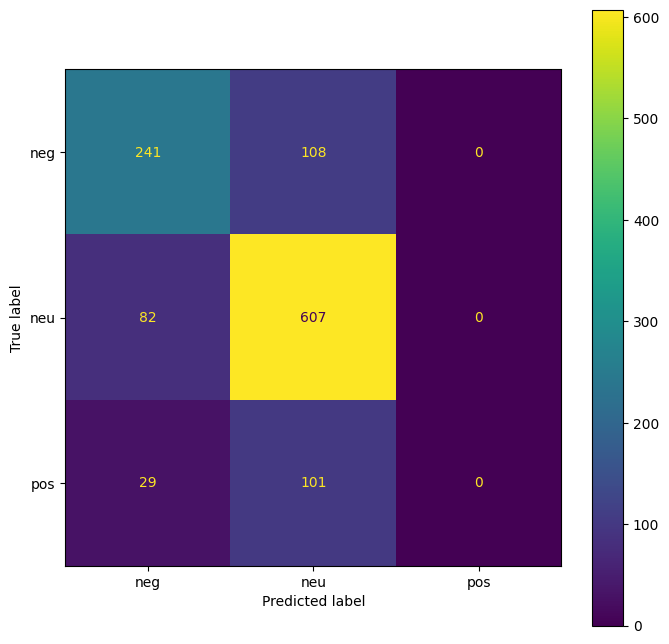

In [ ]:
showConfisionMatrix(y_test, y_pred)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Create an instance of CountVectorizer
# The tokenizer splits the text by '|'
# ngram_range can be set to (1,2) to include unigrams and bigrams
# max_features can limit the number of features to the most frequent ones
vectorizer = CountVectorizer(tokenizer=lambda x: x.split('|'), ngram_range=(1,2), max_features=5000)

# Fit and transform the 'preprocessed' column to get the feature vectors
X_features = vectorizer.fit_transform(simple_analysis['preprocessed'])

print("Text successfully vectorized. Shape of X_features:", X_features.shape)
print("First 5 feature names:\n", vectorizer.get_feature_names_out()[:5])

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Text successfully vectorized. Shape of X_features: (5836, 5000)
First 5 feature names:
 ['a' 'a e' 'a good' 'absolut' 'absolutthailand']


In [ ]:
X = X_features
y = simple_analysis['label']

print("X and y updated with vectorized features.")

X and y updated with vectorized features.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets successfully.
X_train shape: (4668, 5000)
X_test shape: (1168, 5000)
y_train shape: (4668,)
y_test shape: (1168,)


In [ ]:
from sklearn.svm import SVC

svm_model = SVC(random_state=42)
svm_model.fit(X_train, y_train)
print("SVM model trained successfully.")

SVM model trained successfully.


In [ ]:
y_pred = svm_model.predict(X_test)
print("Predictions made on the test set.")

Predictions made on the test set.


Accuracy score: 0.7594


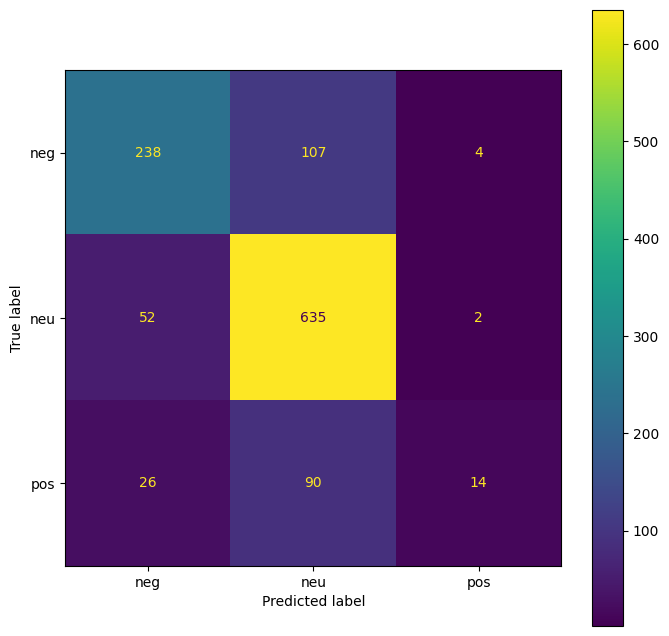

In [ ]:
showConfisionMatrix(y_test, y_pred)

# Accuracy Paradox

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Create an instance of CountVectorizer
# The tokenizer splits the text by '|'
# ngram_range can be set to (1,2) to include unigrams and bigrams
# max_features can limit the number of features to the most frequent ones
vectorizer = CountVectorizer(tokenizer=lambda x: x.split('|'), ngram_range=(1,2), max_features=5000)

# Fit and transform the 'preprocessed' column to get the feature vectors
X_features = vectorizer.fit_transform(simple_analysis['preprocessed'])

print("Text successfully vectorized. Shape of X_features:", X_features.shape)
print("First 5 feature names:\n", vectorizer.get_feature_names_out()[:5])

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Text successfully vectorized. Shape of X_features: (5836, 5000)
First 5 feature names:
 ['a' 'a e' 'a good' 'absolut' 'absolutthailand']


In [ ]:
from scipy.sparse import hstack

# Extract numerical features from simple_analysis
X_numerical = simple_analysis[['num_pos', 'num_neg', 'num_tokens', 'unique_tokens_ratio']]

# Combine text features (sparse matrix) with numerical features (dense matrix)
X = hstack([X_features, X_numerical])
y = simple_analysis['label']

print("Combined feature matrix X and target y created successfully.")
print(f"Shape of combined X: {X.shape}")
print(f"Shape of y: {y.shape}")

Combined feature matrix X and target y created successfully.
Shape of combined X: (5836, 5004)
Shape of y: (5836,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets successfully.
X_train shape: (4668, 5004)
X_test shape: (1168, 5004)
y_train shape: (4668,)
y_test shape: (1168,)


In [ ]:
from sklearn.svm import SVC

svm_model = SVC(random_state=42)
svm_model.fit(X_train, y_train)
print("SVM model trained successfully.")

SVM model trained successfully.


In [ ]:
y_pred = svm_model.predict(X_test)
print("Predictions made on the test set.")

Predictions made on the test set.


Accuracy score: 0.6901


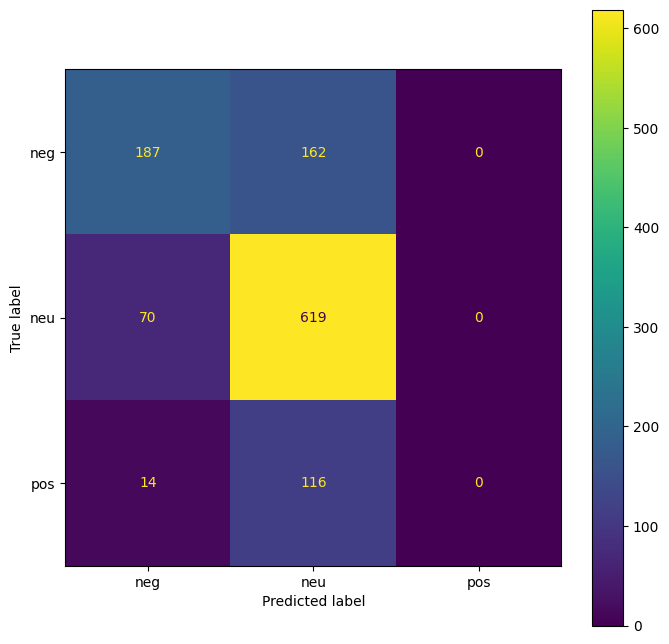

In [ ]:
showConfisionMatrix(y_test, y_pred)

# Undersample Majority Classes

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

# Instantiate RandomUnderSampler with a random_state for reproducibility
rus = RandomUnderSampler(random_state=42)

# Apply the fit_resample method to perform undersampling
X_resampled, y_resampled = rus.fit_resample(X, y)

print("Undersampling performed successfully.")
print(f"Shape of X_resampled: {X_resampled.shape}")
print(f"Shape of y_resampled: {y_resampled.shape}")
print("\nValue counts of y_resampled:")
print(y_resampled.value_counts())

Undersampling performed successfully.
Shape of X_resampled: (1785, 5004)
Shape of y_resampled: (1785,)

Value counts of y_resampled:
label
neg    595
neu    595
pos    595
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

print("Data split into training and testing sets successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets successfully.
X_train shape: (1428, 5004)
X_test shape: (357, 5004)
y_train shape: (1428,)
y_test shape: (357,)


In [ ]:
from sklearn.svm import SVC

# Instantiate SVC with random_state for reproducibility
svm_model = SVC(random_state=42)

# Train the SVM model using the balanced training data
svm_model.fit(X_train, y_train)
print("SVM model trained successfully on balanced data.")

SVM model trained successfully on balanced data.


In [ ]:
y_pred = svm_model.predict(X_test)
print("Predictions made on the test set.")

Predictions made on the test set.


Accuracy score: 0.5882


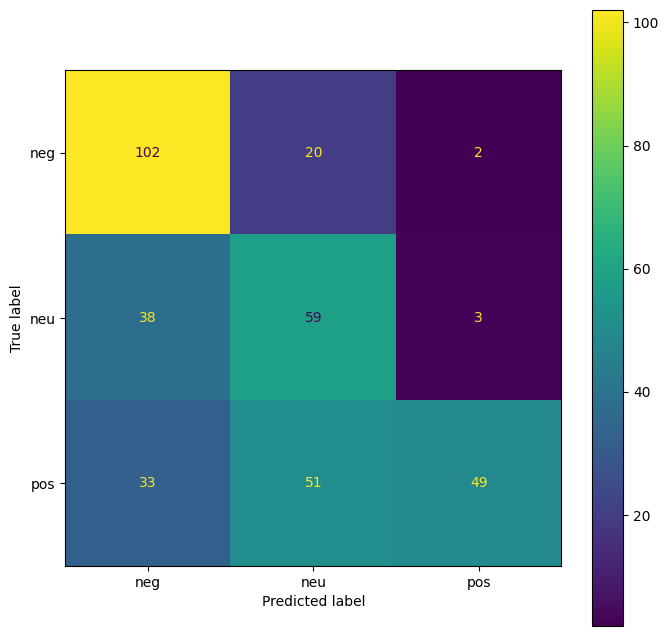

In [ ]:
showConfisionMatrix(y_test, y_pred)

# งานที่ อจ สั่งทำ
- ทำFretrue Engineer เพิ่มมาอีก 3 อัน
  - ไม่จำเป็นต้องได้ค่าความแม่นยำ หรือ f1 สูงขึ้น
  - ต้องมีไอเดียว่าทำอะไรไปบ้าง ทำการเพิ่มหรือลบ หรือใช้ที่มีอยู่
  - เปรียบเทียบกันดูว่าเพิ่ม ลด สร้างใหม่ อันไหนดีกว่ากัน
  - ใช้แค่ svm เทรน
   - ดูว่า f1 ไหนดีที่สุด ทำให้ค่า accuracy เพิ่มขึ้นสูงอีก และได้สูงแค่ไหน

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

indices = np.arange(simple_analysis.shape[0])

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=simple_analysis["label"]
)

In [ ]:
# จำนวนข้อมูลทั้งหมด
n_total = simple_analysis.shape[0]

# จำนวนข้อมูล train / test
n_train = len(train_idx)
n_test = len(test_idx)

print("Total samples:", n_total)
print("Train samples:", n_train)
print("Test samples:", n_test)
print("Train ratio:", n_train / n_total)
print("Test ratio:", n_test / n_total)


Total samples: 5836
Train samples: 4668
Test samples: 1168
Train ratio: 0.7998629198080878
Test ratio: 0.20013708019191226


In [ ]:
# ดู distribution ของ label ทั้งชุด
print("Full dataset")
print(simple_analysis["label"].value_counts(normalize=True))

print("\nTrain set")
print(simple_analysis.loc[train_idx, "label"].value_counts(normalize=True))

print("\nTest set")
print(simple_analysis.loc[test_idx, "label"].value_counts(normalize=True))


Full dataset
label
neu    0.600069
neg    0.297978
pos    0.101953
Name: proportion, dtype: float64

Train set
label
neu    0.600043
neg    0.297986
pos    0.101971
Name: proportion, dtype: float64

Test set
label
neu    0.600171
neg    0.297945
pos    0.101884
Name: proportion, dtype: float64


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

def train_eval_svm_fixed_split(X, y, label, class_weight="balanced"):
    if hasattr(X, "tocsr"):
        X = X.tocsr()

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    svm_model = SVC(
        kernel="linear",
        class_weight="balanced",
        random_state=42
    )
    svm_model.fit(X_train, y_train)
    y_pred = svm_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average="weighted")

    report_dict = classification_report(
        y_test,
        y_pred,
        digits=3,
        zero_division=0,
        output_dict=True
    )

    print("="*60)
    print(f"{label}")
    print(f"Accuracy = {acc:.4f} | F1-score = {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=3, zero_division=0))
    print("Prediction distribution:")
    print(pd.Series(y_pred).value_counts())
    showConfisionMatrix(y_test, y_pred)
    print("="*60)

    return acc, f1, report_dict

In [ ]:
from scipy.sparse import hstack

def make_X(X_text, df_source, cols):
    valid_cols = [c for c in cols if c in df_source.columns]

    X_num = df_source[valid_cols].fillna(0).to_numpy() if valid_cols else None

    if X_text is None:
        if X_num is None:
            raise ValueError("No features to create X from.")
        return X_num

    X_text = X_text.tocsr()
    if X_num is None:
        return X_text

    return hstack([X_text, X_num]).tocsr()

In [ ]:
base6 = ['num_pos', 'num_neg', 'num_neu', 'num_tokens', 'unique_tokens_ratio', 'normalized_sentiment_score']

vectorizer = CountVectorizer(tokenizer=lambda x: x.split('|'), ngram_range=(1,2), max_features=5000)
X_features = vectorizer.fit_transform(simple_analysis['preprocessed'])
y = simple_analysis['label']

print("Baseline features and target re-established.")

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Baseline features and target re-established.


base6: ['num_pos', 'num_neg', 'num_neu', 'num_tokens', 'unique_tokens_ratio', 'normalized_sentiment_score']
BASELINE
Accuracy = 0.7038 | F1-score = 0.7046

Classification Report:
              precision    recall  f1-score   support

         neg      0.644     0.655     0.650       348
         neu      0.789     0.779     0.784       701
         pos      0.393     0.403     0.398       119

    accuracy                          0.704      1168
   macro avg      0.609     0.612     0.611      1168
weighted avg      0.706     0.704     0.705      1168

Prediction distribution:
neu    692
neg    354
pos    122
Name: count, dtype: int64
Accuracy score: 0.7038


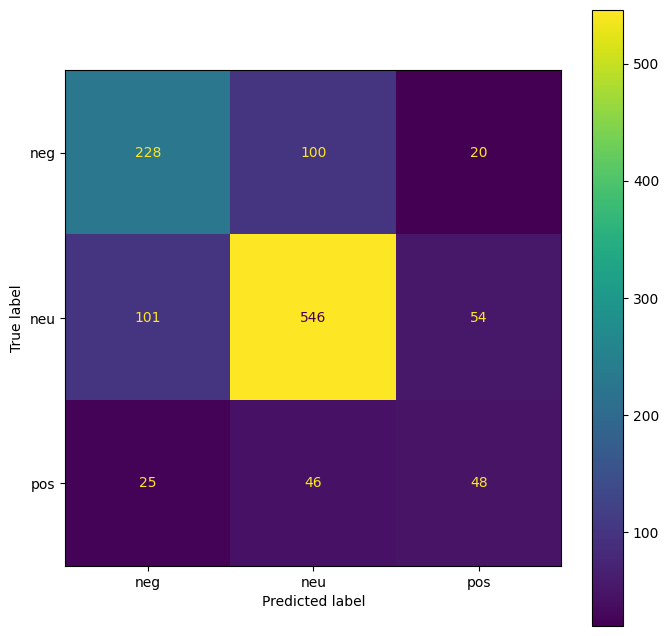

In [ ]:
print("base6:", base6)

X_base = make_X(X_features, simple_analysis, base6)
acc_base, f1_base, report_base = train_eval_svm_fixed_split(X_base, y, "BASELINE")

## 🧪 IDEA 1: Emotion Marker Ratio


IDEA 1: emotion_marker_ratio
Accuracy = 0.7038 | F1-score = 0.7040

Classification Report:
              precision    recall  f1-score   support

         neg      0.637     0.661     0.649       348
         neu      0.790     0.779     0.784       701
         pos      0.397     0.387     0.391       119

    accuracy                          0.704      1168
   macro avg      0.608     0.609     0.608      1168
weighted avg      0.704     0.704     0.704      1168

Prediction distribution:
neu    691
neg    361
pos    116
Name: count, dtype: int64
Accuracy score: 0.7038


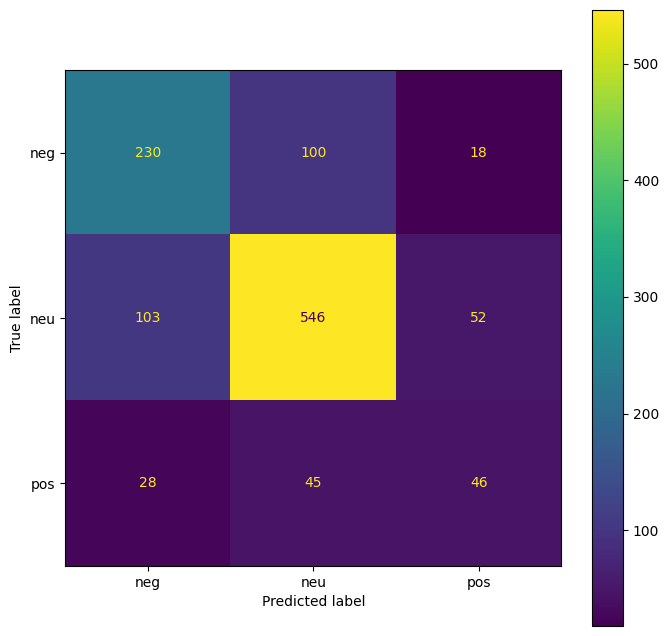

In [ ]:
import re

def is_emotion_marker(tok: str) -> bool:
    """
    ตรวจว่า token นี้เป็น 'ตัวบ่งชี้อารมณ์' (emotion marker) หรือไม่
    เช่น !!! ??? / ลากเสียง มากกก / โคตรรร / 5555
    """
    tok = str(tok)  # กันปัญหา tok เป็น NaN หรือชนิดอื่น

    # 1) เครื่องหมายอารมณ์ซ้ำ ๆ เช่น "!!!", "??", "!?!"
    # ถ้า token มีแต่ ! หรือ ? อย่างเดียว (ยาวเท่าไหร่ก็ได้) => True
    if re.fullmatch(r"[!?]+", tok):
        return True

    # 2) ตัวอักษร/ตัวเลขซ้ำติดกัน >= 3 ตัว เช่น
    # "มากกก" (ก ซ้ำ), "โคตรรร" (ร ซ้ำ), "5555" (5 ซ้ำ)
    # (.)\1\1+ แปลว่า "มีตัวเดิมซ้ำอย่างน้อย 3 ครั้ง"
    if re.search(r"(.)\1\1+", tok):
        return True

    return False

def emotion_marker_ratio(text: str) -> float:
    """
    คำนวณสัดส่วนของ emotion marker ต่อจำนวน token ทั้งหมดในข้อความ
    ratio = (# token ที่เป็น emotion marker) / (# token ทั้งหมด)
    """
    # แปลงเป็น string แล้วแยก token ตามตัวคั่น "|" ที่ใช้ใน preprocessing
    toks = str(text).split("|")

    # ลบ token ว่าง ๆ ออก
    toks = [t for t in toks if t != ""]

    # ถ้าไม่มี token เลย ป้องกันหาร 0
    if len(toks) == 0:
        return 0.0

    # นับจำนวน token ที่เป็น emotion marker แล้วหารด้วยจำนวน token ทั้งหมด
    return sum(is_emotion_marker(t) for t in toks) / len(toks)
    # สร้างคอลัมน์ฟีเจอร์ใหม่
simple_analysis["emotion_marker_ratio"] = (
    simple_analysis["preprocessed"].astype(str).apply(emotion_marker_ratio)
)
# ใช้ base6 เดิม + เพิ่มฟีเจอร์ใหม่ของไอเดีย 1
cols_idea1 = base6 + ["emotion_marker_ratio"]

# base6 + idea1
X_idea1 = make_X(X_features, simple_analysis, cols_idea1)

# ฝึกและประเมินผล SVM
acc_idea1, f1_idea1, report_idea1 = train_eval_svm_fixed_split(
    X_idea1, y, "IDEA 1: emotion_marker_ratio"
)

## 🧪 IDEA 2: Character n-gram

IDEA 2: Character n-gram (3–5)
Accuracy = 0.7046 | F1-score = 0.7074

Classification Report:
              precision    recall  f1-score   support

         neg      0.638     0.698     0.667       348
         neu      0.805     0.759     0.781       701
         pos      0.381     0.403     0.392       119

    accuracy                          0.705      1168
   macro avg      0.608     0.620     0.613      1168
weighted avg      0.712     0.705     0.707      1168

Prediction distribution:
neu    661
neg    381
pos    126
Name: count, dtype: int64
Accuracy score: 0.7046


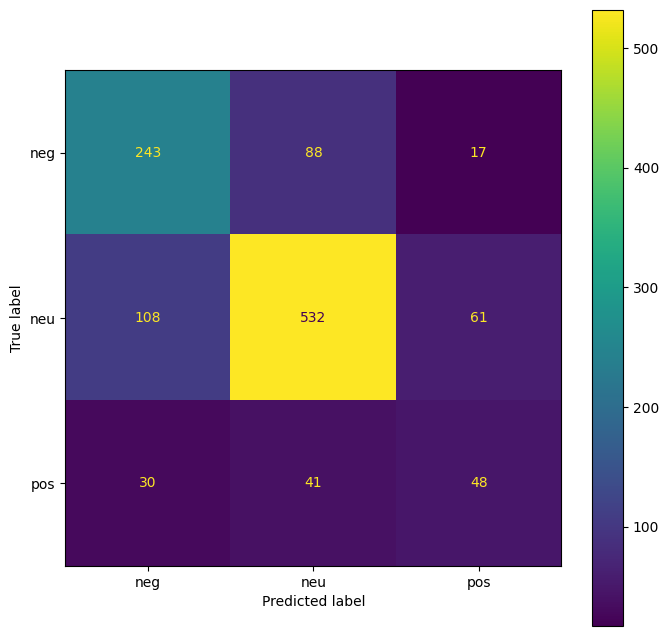

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# เตรียมข้อความสำหรับ character n-gram
# แทนที่ตัวคั่น "|" ด้วยช่องว่าง
# เพื่อให้ CountVectorizer มองข้อความเป็นสตริงต่อเนื่องของตัวอักษร
texts_char = simple_analysis["preprocessed"].str.replace("|", " ", regex=False)

# สร้าง CountVectorizer แบบ character-level
char_vectorizer = CountVectorizer(
    analyzer="char",        # วิเคราะห์ในระดับตัวอักษร ไม่ใช่ระดับคำ
    ngram_range=(3,5),      # ใช้ character n-gram ขนาด 3 ถึง 5 ตัวอักษร
    max_features=5000       # จำกัดจำนวนฟีเจอร์สูงสุด
)

# แปลงข้อความเป็น sparse matrix ของ character n-gram
X_char = char_vectorizer.fit_transform(texts_char)

# รวม character n-gram features กับ numeric baseline features (base6)
X_idea2 = make_X(X_char, simple_analysis, base6)

# ฝึกและประเมินผล SVM โดยใช้ train/test split เดิม
acc_idea2, f1_idea2, report_idea2 = train_eval_svm_fixed_split(
    X_idea2, y, "IDEA 2: Character n-gram (3–5)"
)


## 🧪 IDEA 3: Feature Construction

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


IDEA 3: ngram(1,3)
Accuracy = 0.7175 | F1-score = 0.7169

Classification Report:
              precision    recall  f1-score   support

         neg      0.670     0.675     0.672       348
         neu      0.793     0.795     0.794       701
         pos      0.400     0.387     0.393       119

    accuracy                          0.717      1168
   macro avg      0.621     0.619     0.620      1168
weighted avg      0.716     0.717     0.717      1168

Prediction distribution:
neu    702
neg    351
pos    115
Name: count, dtype: int64
Accuracy score: 0.7175


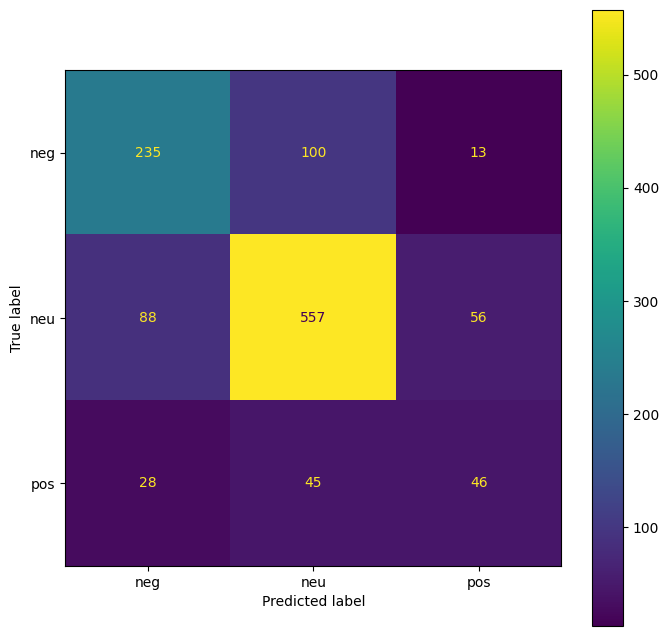

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# เตรียมข้อความที่ผ่านการ preprocessing แล้ว
# แปลงเป็น string เพื่อป้องกันปัญหา NaN หรือชนิดข้อมูลอื่น
texts = simple_analysis["preprocessed"].astype(str)

# สร้าง CountVectorizer แบบ word-level สำหรับไอเดียที่ 3
vectorizer_idea3 = CountVectorizer(
    tokenizer=lambda x: x.split("|"),  # ใช้ tokenizer เดิมจาก preprocessing (แยกด้วย '|')
    ngram_range=(1,3),                 # ใช้ unigram, bigram และ trigram
    max_features=5000,                 # จำกัดจำนวนฟีเจอร์เพื่อควบคุมมิติข้อมูล
    lowercase=False                    # ไม่แปลงเป็นตัวพิมพ์เล็ก เพราะ preprocess ไปแล้ว
)

# แปลงข้อความเป็น sparse matrix ของ word n-gram (1–3)
X_ngram13 = vectorizer_idea3.fit_transform(texts)

# รวม word n-gram features กับ numeric baseline features (base6)
X_idea3 = make_X(X_ngram13, simple_analysis, base6)

# ฝึกและประเมินผลโมเดล SVM โดยใช้ train/test split เดิม
acc_idea3, f1_idea3, report_idea3 = train_eval_svm_fixed_split(
    X_idea3, y, "IDEA 3: ngram(1,3)"
)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


IDEA 3: ngram(1,3)
Accuracy = 0.7517 | F1-score = 0.7461

Classification Report:
              precision    recall  f1-score   support

         neg      0.708     0.698     0.703       348
         neu      0.798     0.842     0.819       701
         pos      0.523     0.378     0.439       119

    accuracy                          0.752      1168
   macro avg      0.677     0.639     0.654      1168
weighted avg      0.744     0.752     0.746      1168

Prediction distribution:
neu    739
neg    343
pos     86
Name: count, dtype: int64
Accuracy score: 0.7517


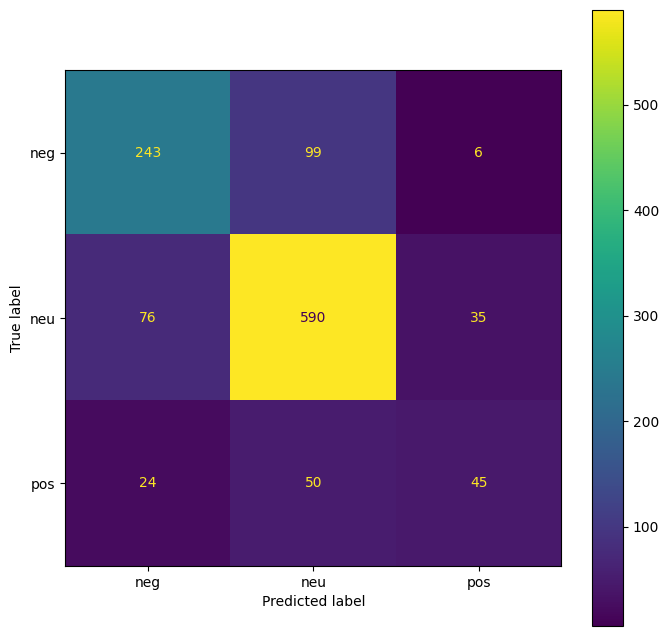

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# เตรียมข้อความที่ผ่านการ preprocessing แล้ว
# แปลงเป็น string เพื่อป้องกันปัญหา NaN หรือชนิดข้อมูลอื่น
texts = simple_analysis["preprocessed"].astype(str)

# สร้าง CountVectorizer แบบ word-level สำหรับไอเดียที่ 3
vectorizer_idea3 = CountVectorizer(
    tokenizer=lambda x: x.split("|"),  # ใช้ tokenizer เดิมจาก preprocessing (แยกด้วย '|')
    ngram_range=(1,3),                 # ใช้ unigram, bigram และ trigram
    max_features=50000,                 # จำกัดจำนวนฟีเจอร์เพื่อควบคุมมิติข้อมูล
    lowercase=False                    # ไม่แปลงเป็นตัวพิมพ์เล็ก เพราะ preprocess ไปแล้ว
)

# แปลงข้อความเป็น sparse matrix ของ word n-gram (1–3)
X_ngram13 = vectorizer_idea3.fit_transform(texts)

# รวม word n-gram features กับ numeric baseline features (base6)
X_idea3 = make_X(X_ngram13, simple_analysis, base6)

# ฝึกและประเมินผลโมเดล SVM
acc_idea3, f1_idea3, report_idea3 = train_eval_svm_fixed_split(
    X_idea3, y, "IDEA 3: ngram(1,3)"
)

In [ ]:
import pandas as pd

results = pd.DataFrame([
    {"Experiment":"BASELINE", "Accuracy":acc_base, "F1-score":f1_base},
    {"Experiment":"IDEA 1", "Accuracy":acc_idea1, "F1-score":f1_idea1},
    {"Experiment":"IDEA 2", "Accuracy":acc_idea2, "F1-score":f1_idea2},
    {"Experiment":"IDEA 3", "Accuracy":acc_idea3, "F1-score":f1_idea3}

]).sort_values("F1-score", ascending=False)

results

,Experiment,Accuracy,F1-score
3,IDEA 3,0.751712,0.746090
2,IDEA 2,0.704623,0.707408
0,BASELINE,0.703767,0.704607
1,IDEA 1,0.703767,0.704018


In [ ]:
print("Text feature shape:", X_char.shape)
cols_idea2 = base6 # Define cols_idea2 as base6, which were the numeric features for IDEA 2
print("Numeric features used:", cols_idea2)
X_idea2 = make_X(X_char, simple_analysis, cols_idea2) # Use X_char for text features for IDEA 2
print("Final X shape (IDEA 2):", X_idea2.shape)

Text feature shape: (5836, 5000)
Numeric features used: ['num_pos', 'num_neg', 'num_neu', 'num_tokens', 'unique_tokens_ratio', 'normalized_sentiment_score']
Final X shape (IDEA 2): (5836, 5006)


In [ ]:
# IDEA 3: n-gram(1,3) - check dimensions

print("IDEA 3 (ngram 1-3) text feature shape:", X_ngram13.shape)

# ถ้า IDEA 3 ยังใช้ numeric baseline เดิม (base6)
cols_idea3 = base6
X_idea3 = make_X(X_ngram13, simple_analysis, cols_idea3)

print("Numeric features used (IDEA 3):", cols_idea3)
print("Final X shape (IDEA 3):", X_idea3.shape)

# (Optional) ดูว่ามีวลีจริงไหม
print("\nSample n-gram tokens from vocabulary:")
print(list(vectorizer_idea3.vocabulary_.keys())[:30])


IDEA 3 (ngram 1-3) text feature shape: (5836, 50000)
Numeric features used (IDEA 3): ['num_pos', 'num_neg', 'num_neu', 'num_tokens', 'unique_tokens_ratio', 'normalized_sentiment_score']
Final X shape (IDEA 3): (5836, 50006)

Sample n-gram tokens from vocabulary:
['เน็ต', 'ควาย', 'เสียดาย', 'ตังค์', 'ติดตั้ง', 'โค', 'รต', 'ห่วย', 'ดึก', 'ตอน', 'ติด', 'แย่', 'กาก', 'ค่าย', 'อ่ะ', 'สน', 'หรอ', 'เด็ก', 'เม้น', 'ด่า', 'แบบนี้', 'หา', 'จ่าย', 'ค่า', 'เหนื่อย', 'เล่น', 'เกมส์', 'เดี่ยว', 'หาย', 'โปร']
